<a href="https://colab.research.google.com/github/deepto123/Neural-Networks-and-LLMs/blob/main/Understanding_activations_and_gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

g = torch.Generator().manual_seed(2147483647)

In [ ]:
names = open('/content/drive/MyDrive/Learning LLMs/names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(names))))
stoi = {ch:i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
context_window = 3

def build_dataset(words):

  xs = []
  ys = []
  for name in words:
    string = ['.'] *3 + list(name) + ['.']
    for i in range(len(string) - context_window):
      context = [stoi[ch] for ch in string[i:i+context_window]]
      output = stoi[string[i+context_window]]

      xs.append(context)
      ys.append(output)

  xs = torch.tensor(xs)
  ys = torch.tensor(ys)
  return xs, ys

import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

print(n1)
print(n2)
x_train, y_train = build_dataset(names[:n1])
x_val, y_val = build_dataset(names[n1:n2])
x_test, y_test = build_dataset(names[n2:])

25626
28829


In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias = True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.randn(fan_out, generator=g) if bias else None

  def __call__(self, input):
    self.out = input @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])



In [ ]:
class Tanh:
  def __call__(self, input):
    self.out = torch.tanh(input)
    return self.out

  def parameters(self):
    return []


In [ ]:
n_embedding = 10
n_hidden = 100
vocab_size = 27

C = torch.randn((vocab_size, n_embedding), generator=g)

layers = [
    Linear(context_window * n_embedding, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

# We should never track grad during normalisation, tell the model forget the scaling and accept the new baseline truth
with torch.no_grad():
  # make the last layer less confident so that initial loss is less and we dont get a hockey stick
  layers[-1].weight *=.1
  # for other layers apply the standard gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]

# Print the shape of each tensor in the parameters list
for i, p in enumerate(parameters):
    print(f"Tensor {i}: {p.shape}")

print(sum(p.nelement() for p in parameters)) ## number of params in total
for p in parameters:
  p.requires_grad = True


Tensor 0: torch.Size([27, 10])
Tensor 1: torch.Size([30, 100])
Tensor 2: torch.Size([100])
Tensor 3: torch.Size([100, 100])
Tensor 4: torch.Size([100])
Tensor 5: torch.Size([100, 100])
Tensor 6: torch.Size([100])
Tensor 7: torch.Size([100, 100])
Tensor 8: torch.Size([100])
Tensor 9: torch.Size([100, 100])
Tensor 10: torch.Size([100])
Tensor 11: torch.Size([100, 27])
Tensor 12: torch.Size([27])
46497


In [ ]:
max_steps = 200000
batch_size = 32
losses = []
update_to_data_ratio = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  emb = C[x_batch] # get embedding of the batch returned
  out = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, y_batch) # softmax activation and loss caculation

  # backward pass
  for layer in layers:
    layer.out.retain_grad()   # ask pytorvh to retain gards for hidden layers
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.05 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track metrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph

  with torch.no_grad():
    # comapre how much the update/learning shifted from the mean compared to how much the data has shifted from the mean
    update_to_data_ratio.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if (i==1000):
    break;


step:0, loss: 3.6064


layer 1 (      Tanh): mean -0.06, std 0.79, saturated: 29.47%
layer 3 (      Tanh): mean +0.04, std 0.75, saturated: 19.31%
layer 5 (      Tanh): mean +0.02, std 0.74, saturated: 17.72%
layer 7 (      Tanh): mean -0.05, std 0.72, saturated: 14.22%
layer 9 (      Tanh): mean -0.02, std 0.73, saturated: 15.28%


/tmp/ipykernel_4844/3695027216.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

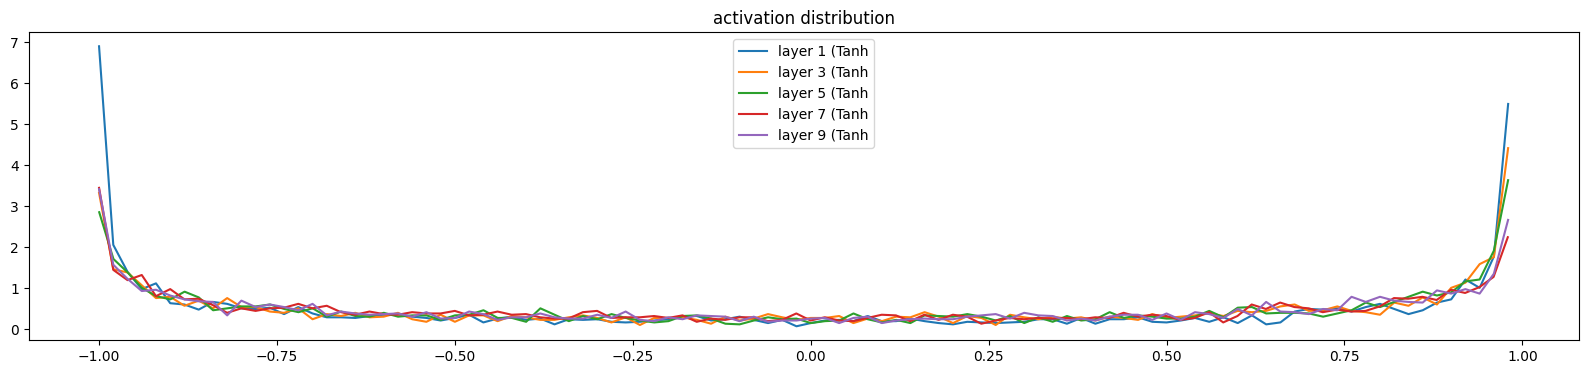

In [ ]:
# visulaize histograms

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

# we should target for kamming init, the layers start becoming unsaturated

layer 1 (      Tanh): mean +0.000038, std 3.269249e-03
layer 3 (      Tanh): mean -0.000057, std 3.163413e-03
layer 5 (      Tanh): mean -0.000035, std 2.929402e-03
layer 7 (      Tanh): mean +0.000076, std 2.569710e-03
layer 9 (      Tanh): mean -0.000034, std 2.028429e-03


Text(0.5, 1.0, 'gradient distribution')

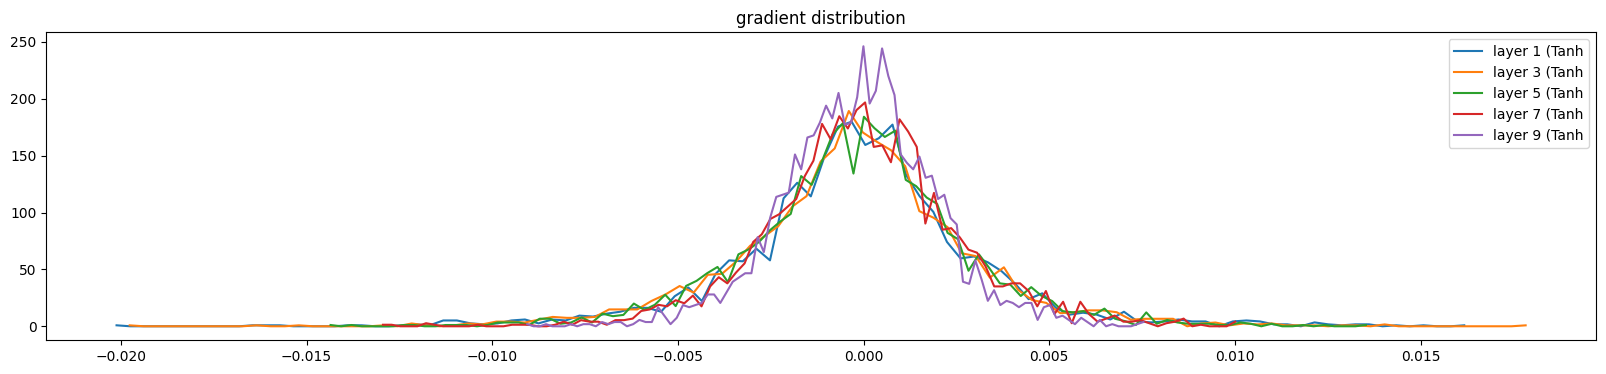

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

# we should target for a kamming init such that the gradient curve remains the same over all the layers

In [ ]:
# Without the tanh, if we stack liner layers one upon the other, we basically get outouts as a fucntion of linear layers only.
# So it does no good keeping n layers instead of 1

weight   (27, 10) | mean -0.001119 | std 1.031862e-02 | grad:data ratio 1.029898e-02
weight  (30, 100) | mean -0.000169 | std 9.725838e-03 | grad:data ratio 3.113428e-02
weight (100, 100) | mean +0.000043 | std 8.134887e-03 | grad:data ratio 4.856985e-02
weight (100, 100) | mean -0.000032 | std 7.701679e-03 | grad:data ratio 4.634405e-02
weight (100, 100) | mean +0.000024 | std 7.283301e-03 | grad:data ratio 4.348824e-02
weight (100, 100) | mean +0.000059 | std 5.427794e-03 | grad:data ratio 3.229265e-02
weight  (100, 27) | mean +0.000000 | std 2.441072e-02 | grad:data ratio 4.321060e-01


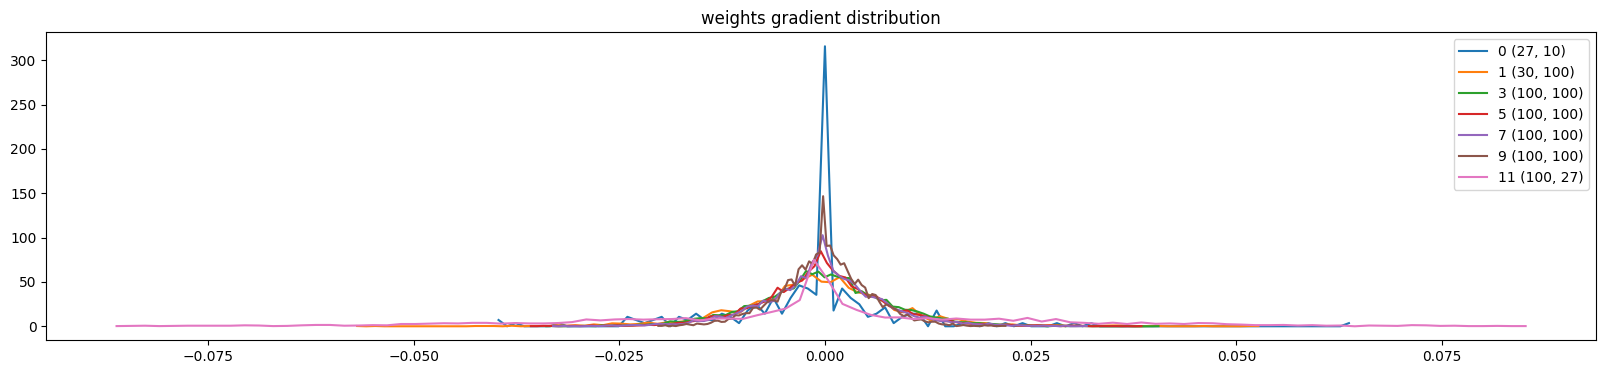

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [ ]:
# Initially, we had initialised with weights with *=.1, so the grad:data ratio is much larger than others for the output layer
# The standard deviation is 10 times that of all the previous layers that means in a simple stochastic gradient setup, we will
# be training the output layer 10 times faster than our inner layer.

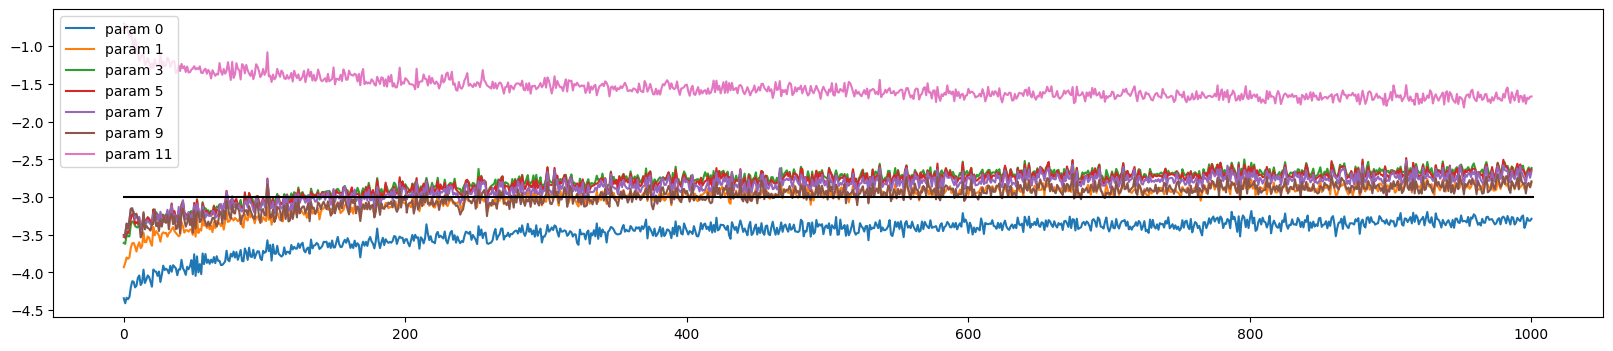

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:  # only plot for weights
    plt.plot([update_to_data_ratio[j][i] for j in range(len(update_to_data_ratio))])
    legends.append('param %d' % i)
plt.plot([0, len(update_to_data_ratio)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


Now lets do this activity for Batch Normalisation

In [ ]:
class BatchNorm1d:
  def __init__(self,num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True):
    self.eps = eps
    self.momentum = momentum
    self.training = track_running_stats

    #  parameters(trained with backprop)
    self.gamma = torch.ones(num_features) # equivalent to batch norm gain
    self.beta = torch.zeros(num_features) # equivalent to batch norm bias

    # buffers (trained with a )
    self.running_mean = torch.zeros(num_features)
    self.running_var = torch.ones(num_features)

  def __call__(self, input):

    if self.training:
      current_mean = input.mean(0, keepdim = True)
      current_var = input.var(0, keepdim = True)
    else:
      current_mean = self.running_mean
      current_var = self.running_var

    # Step 1:- substract from mean and divide by stnd deviation
    input_hat = (input - current_mean)/ torch.sqrt(current_var + self.eps)

    # Step 2:scale and shift
    self.out = self.gamma * input_hat + self.beta

    # recalculate the running mean
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * current_mean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * current_var

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]



In [ ]:
n_embedding = 10
n_hidden = 100
vocab_size = 27

C = torch.randn((vocab_size, n_embedding), generator=g)

layers = [
    Linear(context_window * n_embedding, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size) # its perfecty fine to plave it after the last layer
]

# We should never track grad during normalisation, tell the model forget the scaling and accept the new baseline truth
with torch.no_grad():
  # make the last layer less confident so that initial loss is less and we dont get a hockey stick
  layers[-1].gamma *=.1
  # for other layers apply the standard gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]

# Print the shape of each tensor in the parameters list
for i, p in enumerate(parameters):
    print(f"Tensor {i}: {p.shape}")

print(sum(p.nelement() for p in parameters)) ## number of params in total
for p in parameters:
  p.requires_grad = True


Tensor 0: torch.Size([27, 10])
Tensor 1: torch.Size([30, 100])
Tensor 2: torch.Size([100])
Tensor 3: torch.Size([100])
Tensor 4: torch.Size([100])
Tensor 5: torch.Size([100, 100])
Tensor 6: torch.Size([100])
Tensor 7: torch.Size([100])
Tensor 8: torch.Size([100])
Tensor 9: torch.Size([100, 100])
Tensor 10: torch.Size([100])
Tensor 11: torch.Size([100])
Tensor 12: torch.Size([100])
Tensor 13: torch.Size([100, 100])
Tensor 14: torch.Size([100])
Tensor 15: torch.Size([100])
Tensor 16: torch.Size([100])
Tensor 17: torch.Size([100, 100])
Tensor 18: torch.Size([100])
Tensor 19: torch.Size([100])
Tensor 20: torch.Size([100])
Tensor 21: torch.Size([100, 27])
Tensor 22: torch.Size([27])
Tensor 23: torch.Size([27])
Tensor 24: torch.Size([27])
47551


In [ ]:
max_steps = 200000
batch_size = 32
losses = []
update_to_data_ratio = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  emb = C[x_batch] # get embedding of the batch returned
  out = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, y_batch) # softmax activation and loss caculation

  # backward pass
  for layer in layers:
    layer.out.retain_grad()   # ask pytorvh to retain gards for hidden layers
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.05 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track metrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph

  with torch.no_grad():
    # comapre how much the update/learning shifted from the mean compared to how much the data has shifted from the mean
    update_to_data_ratio.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])


step:0, loss: 3.2629
step:10000, loss: 2.3737
step:20000, loss: 2.3335
step:30000, loss: 2.9404
step:40000, loss: 2.2734
step:50000, loss: 2.4567
step:60000, loss: 2.1967
step:70000, loss: 1.9759
step:80000, loss: 2.4306
step:90000, loss: 2.3410
step:100000, loss: 1.8111
step:110000, loss: 2.6318
step:120000, loss: 2.2783
step:130000, loss: 2.1692
step:140000, loss: 1.7820
step:150000, loss: 2.0488
step:160000, loss: 2.2985
step:170000, loss: 2.2822
step:180000, loss: 2.0981
step:190000, loss: 2.1914


layer 2 (      Tanh): mean -0.01, std 0.70, saturated: 10.75%
layer 5 (      Tanh): mean -0.00, std 0.72, saturated: 12.47%
layer 8 (      Tanh): mean -0.01, std 0.73, saturated: 13.03%
layer 11 (      Tanh): mean -0.02, std 0.74, saturated: 12.03%
layer 14 (      Tanh): mean -0.01, std 0.74, saturated: 14.22%


Text(0.5, 1.0, 'activation distribution')

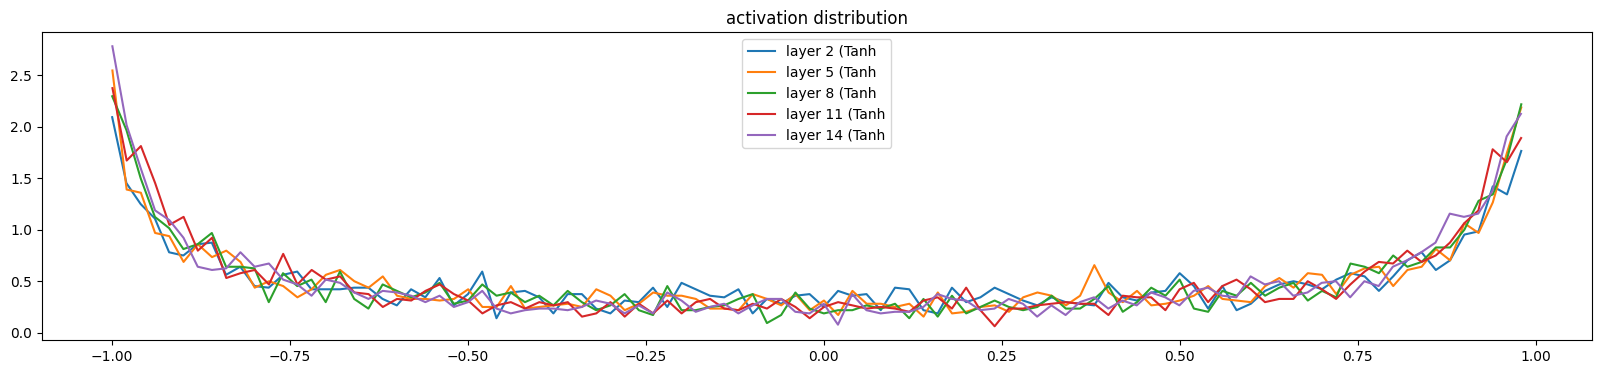

In [ ]:
# visulaize histograms

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

# we should target for kamming init, the layers start becoming unsaturated

layer 2 (      Tanh): mean -0.000000, std 4.158502e-03
layer 5 (      Tanh): mean +0.000000, std 4.322152e-03
layer 8 (      Tanh): mean +0.000000, std 4.322449e-03
layer 11 (      Tanh): mean -0.000000, std 4.092486e-03
layer 14 (      Tanh): mean +0.000000, std 3.834669e-03


Text(0.5, 1.0, 'gradient distribution')

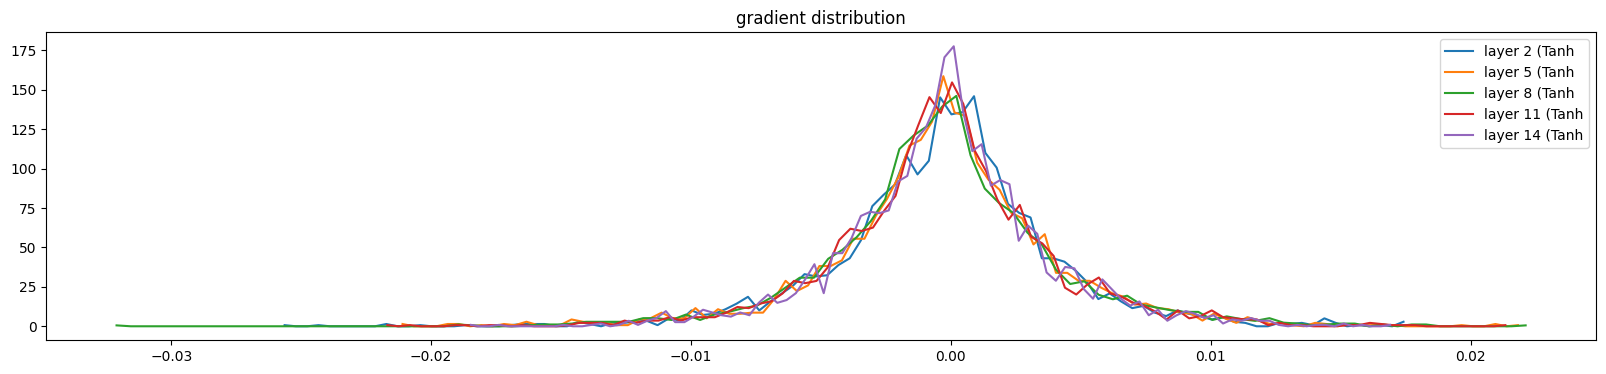

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

# we should target for a kamming init such that the gradient curve remains the same over all the layers

In [ ]:
# Without the tanh, if we stack liner layers one upon the other, we basically get outouts as a fucntion of linear layers only.
# So it does no good keeping n layers instead of 1

weight   (27, 10) | mean +0.000000 | std 1.659521e-02 | grad:data ratio 1.528411e-02
weight  (30, 100) | mean -0.000126 | std 1.359502e-02 | grad:data ratio 4.964872e-02
weight (100, 100) | mean -0.000049 | std 9.222246e-03 | grad:data ratio 5.568142e-02
weight (100, 100) | mean +0.000091 | std 9.970887e-03 | grad:data ratio 6.035863e-02
weight (100, 100) | mean +0.000024 | std 9.122672e-03 | grad:data ratio 5.702402e-02
weight (100, 100) | mean -0.000009 | std 8.544627e-03 | grad:data ratio 5.591857e-02
weight  (100, 27) | mean -0.000029 | std 1.251079e-02 | grad:data ratio 5.432630e-02


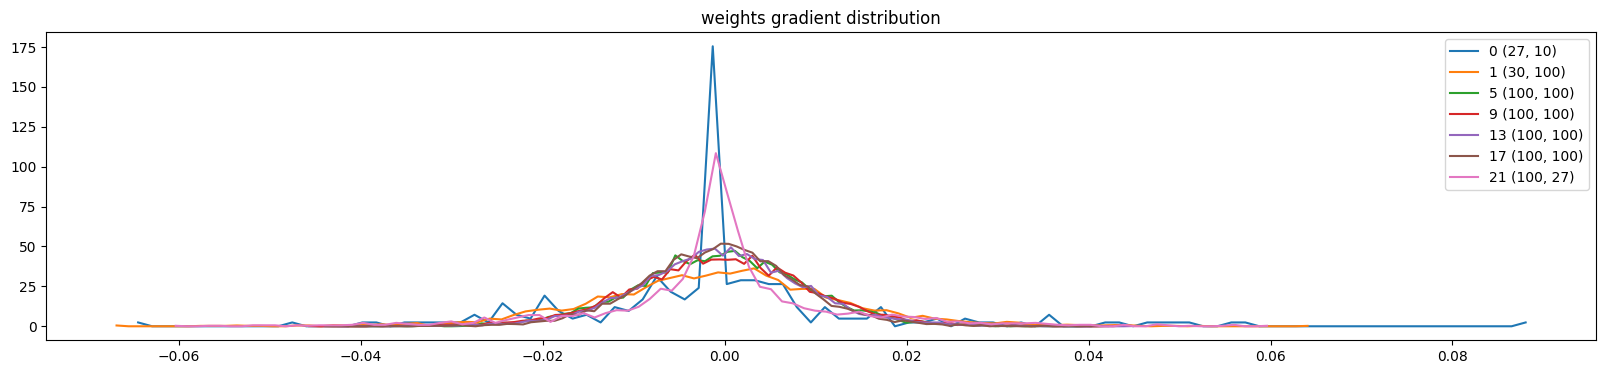

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [ ]:
# For the puter layer, we had initialised with weights with *=.1, so the grad:data ratio is much larger than others for the output layer
# The standard deviation is 10 times that of all the previous layers that means in a simple stochastic gradient setup, we will
# be training the output layer 10 times faster than our inner layer.

# if gradients have high standard deviation, the learning rate increases

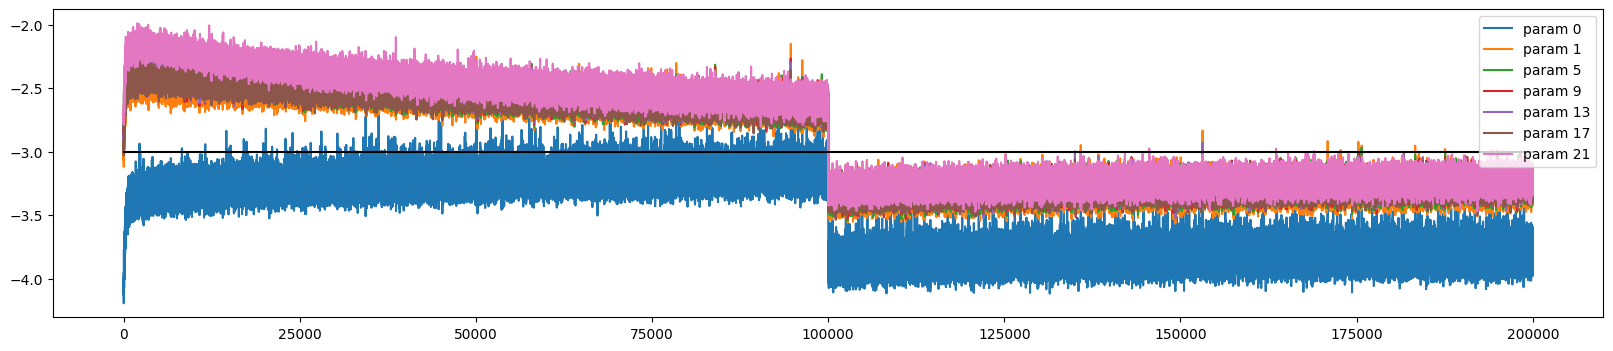

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:  # only plot for weights
    plt.plot([update_to_data_ratio[j][i] for j in range(len(update_to_data_ratio))])
    legends.append('param %d' % i)
plt.plot([0, len(update_to_data_ratio)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [ ]:
# However if we reduce the kamming init, all the plots remain same except the learning rate plot which decreases signmificantly. This
# is because reducing the weights have a compunding effect on the gradients which reduces faster and hence a lower learning rate

In [ ]:
# before calculating the training and val losses set the training to false
for layer in layers:
  layer.training = False

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  emb = C[x] # get embedding of the batch returned
  out = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, y) # softmax activation and loss caculation
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.015129327774048
val 2.0859551429748535


In [ ]:
for _ in range(20):

    result = []
    context = [0] * context_window # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      out = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        out = layer(out)
      logits = out
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      result.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in result)) # decode and print the generated word

rod.
darleighten.
son.
payanusummer.
avenasthansere.
jaaklee.
rididonix.
mulaan.
fakyan.
hayesha.
haelissa.
andree.
nie.
dabela.
asulessifaathan.
cakynzleighs.
tafanna.
kamyeleigh.
cas.
markind.


In [ ]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):

  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


/tmp/ipykernel_4844/2622984446.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  losses = torch.tensor(losses)


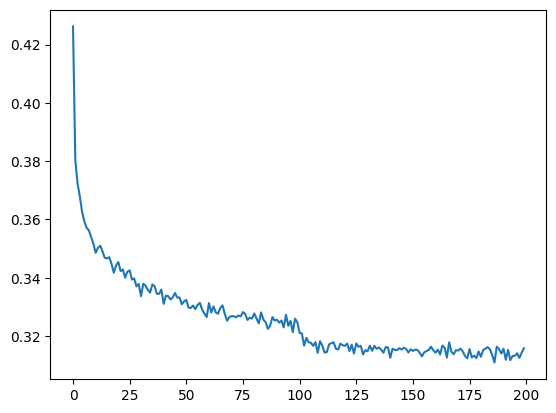

In [ ]:
losses = torch.tensor(losses)
losses_batch = losses.view(-1, 1000).mean(dim = 1, keepdim = True)

plt.plot(losses_batch)